In [1]:
import torch

In [2]:
X =torch.tensor([[1.0,4.0,7.0], [2.0,3.0,6.0]])
X

tensor([[1., 4., 7.],
        [2., 3., 6.]])

In [3]:
X.shape

torch.Size([2, 3])

In [4]:
X.dtype

torch.float32

In [5]:
X[0,1]

tensor(4.)

In [6]:
X[:,1]

tensor([4., 3.])

In [7]:
10 * (X + 1.0)

tensor([[20., 50., 80.],
        [30., 40., 70.]])

In [8]:
X.exp()

tensor([[   2.7183,   54.5981, 1096.6332],
        [   7.3891,   20.0855,  403.4288]])

In [9]:
X.mean()

tensor(3.8333)

In [10]:
X.max(dim=0)

torch.return_types.max(
values=tensor([2., 4., 7.]),
indices=tensor([1, 0, 0]))

In [11]:
X @ X.T

tensor([[66., 56.],
        [56., 49.]])

In [12]:
import numpy as np
X.numpy()

array([[1., 4., 7.],
       [2., 3., 6.]], dtype=float32)

In [13]:
torch.tensor(np.array([[1.,4.,7.],[2.,3.,6.]]))

tensor([[1., 4., 7.],
        [2., 3., 6.]], dtype=torch.float64)

In [14]:
torch.FloatTensor(np.array([[1.,4.,7.],[2.,3.,6.]]))

tensor([[1., 4., 7.],
        [2., 3., 6.]])

In [15]:
X[:,1] = -99
X

tensor([[  1., -99.,   7.],
        [  2., -99.,   6.]])

In [16]:
X.relu_()
X

tensor([[1., 0., 7.],
        [2., 0., 6.]])

In [17]:
if torch.cuda.is_available():
    device = 'cuda'
elif torch.backends.mps.is_available():
    device = 'mps'
else:
    device = 'cpu'
device

'cuda'

In [18]:
M = torch.tensor([[1.,4.,7.],[2.,3.,6.]])
M = M.to(device)

In [19]:
M.device

device(type='cuda', index=0)

In [20]:
M = torch.tensor([[1.,4.,7.],[2.,3.,6.]], device = device)

In [21]:
R = M @ M.T
R

tensor([[66., 56.],
        [56., 49.]], device='cuda:0')

In [22]:
M = torch.rand((1000,1000))
%timeit M @ M.T

17.3 ms ± 3.03 ms per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [23]:
# M = torch.rand((1000,1000), device = 'cuda')
# %timeit M @ M.T

In [24]:
x = torch.tensor(5.0, requires_grad = True)
f = x ** 2
f

tensor(25., grad_fn=<PowBackward0>)

In [25]:
f.backward()

In [26]:
x.grad

tensor(10.)

In [27]:
learning_rate = 0.1
with torch.no_grad():
    x -= learning_rate * x.grad

In [28]:
x

tensor(4., requires_grad=True)

In [29]:
x_detached = x.detach()
x_detached -= learning_rate * x.grad

In [30]:
x.grad.zero_()

tensor(0.)

In [31]:
learning_rate = 0.1
x = torch.tensor(5.0,requires_grad=True)
for iteration in range(100):
    f = x ** 2 #forward pass
    f.backward() #backward pass
    with torch.no_grad():
        x -= learning_rate * x.grad # gradient descent step

    x.grad.zero_() # reset gradients

In [32]:
# t = torch.tensor(2.0, requires_grad = True)
# z = t.exp()
# z += 1
# z.backward()

In [33]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

housing = fetch_california_housing()
X_train_full, X_test, y_train_full, y_test = train_test_split(
    housing.data, housing.target, random_state=42)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full, y_train_full, random_state=42)

In [34]:
X_train = torch.FloatTensor(X_train)
X_valid = torch.FloatTensor(X_valid)
X_test = torch.FloatTensor(X_test)
means = X_train.mean(dim=0, keepdims=True)
stds = X_train.std(dim=0, keepdims=True)
X_train = (X_train - means) / stds
X_valid = (X_valid - means) / stds
X_test = (X_test - means) / stds

In [35]:
y_train =  torch.FloatTensor(y_train).reshape(-1,1)
y_valid = torch.FloatTensor(y_valid).reshape(-1,1)
y_test = torch.FloatTensor(y_test).reshape(-1,1)

In [36]:
torch.manual_seed(42)
n_features = X_train.shape[1]
w = torch.randn((n_features , 1), requires_grad = True)
b = torch.tensor(0., requires_grad = True)

In [37]:
learning_rate = 0.4
n_epochs = 20
for epoch in range(n_epochs):
    y_pred = X_train @ w + b
    loss = ((y_pred - y_train) ** 2).mean()
    loss.backward()
    with torch.no_grad():
        b -= learning_rate * b.grad
        w -= learning_rate * w.grad
        b.grad.zero_()
        w.grad.zero_()
    print(f'Epoch {epoch + 1} / {n_epochs}, Loss: {loss.item()}')

Epoch 1 / 20, Loss: 16.158456802368164
Epoch 2 / 20, Loss: 4.8793745040893555
Epoch 3 / 20, Loss: 2.255225419998169
Epoch 4 / 20, Loss: 1.3307634592056274
Epoch 5 / 20, Loss: 0.9680691957473755
Epoch 6 / 20, Loss: 0.8142675757408142
Epoch 7 / 20, Loss: 0.7417045831680298
Epoch 8 / 20, Loss: 0.7020701169967651
Epoch 9 / 20, Loss: 0.6765918731689453
Epoch 10 / 20, Loss: 0.6577965021133423
Epoch 11 / 20, Loss: 0.6426151990890503
Epoch 12 / 20, Loss: 0.6297222971916199
Epoch 13 / 20, Loss: 0.6184942126274109
Epoch 14 / 20, Loss: 0.6085968613624573
Epoch 15 / 20, Loss: 0.5998216867446899
Epoch 16 / 20, Loss: 0.592018723487854
Epoch 17 / 20, Loss: 0.5850691795349121
Epoch 18 / 20, Loss: 0.578873336315155
Epoch 19 / 20, Loss: 0.573345422744751
Epoch 20 / 20, Loss: 0.5684100389480591


In [38]:
X_new = X_test[:3]
with torch.no_grad():
    y_pred = X_new @ w + b
y_pred

tensor([[0.8916],
        [1.6480],
        [2.6577]])

In [39]:
import torch.nn as nn

torch.manual_seed(42)
model = nn.Linear(in_features = n_features, out_features = 1)

In [40]:
model.bias

Parameter containing:
tensor([0.3117], requires_grad=True)

In [41]:
model.weight

Parameter containing:
tensor([[ 0.2703,  0.2935, -0.0828,  0.3248, -0.0775,  0.0713, -0.1721,  0.2076]],
       requires_grad=True)

In [42]:
for param in model.parameters():
    print(param)

Parameter containing:
tensor([[ 0.2703,  0.2935, -0.0828,  0.3248, -0.0775,  0.0713, -0.1721,  0.2076]],
       requires_grad=True)
Parameter containing:
tensor([0.3117], requires_grad=True)


In [43]:
model(X_train[:2])

tensor([[-0.4718],
        [ 0.1131]], grad_fn=<AddmmBackward0>)

In [44]:
optimizer = torch.optim.SGD(model.parameters(), lr = learning_rate)
mse = nn.MSELoss()

In [45]:
def train_bgd(model, optimizer, criterion, X_train, y_train, n_epochs):
    for epoch in range(n_epochs):
        y_pred = model(X_train)
        loss = criterion(y_pred, y_train)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        print(f"Epoch {epoch + 1} / {n_epochs}, Loss: {loss.item()}")

In [46]:
train_bgd(model, optimizer, mse, X_train, y_train, n_epochs)

Epoch 1 / 20, Loss: 4.3378496170043945
Epoch 2 / 20, Loss: 0.7802939414978027
Epoch 3 / 20, Loss: 0.6253842115402222
Epoch 4 / 20, Loss: 0.6060433983802795
Epoch 5 / 20, Loss: 0.5956299304962158
Epoch 6 / 20, Loss: 0.587356686592102
Epoch 7 / 20, Loss: 0.5802990794181824
Epoch 8 / 20, Loss: 0.5741382837295532
Epoch 9 / 20, Loss: 0.5687101483345032
Epoch 10 / 20, Loss: 0.5639079809188843
Epoch 11 / 20, Loss: 0.5596511363983154
Epoch 12 / 20, Loss: 0.5558737516403198
Epoch 13 / 20, Loss: 0.5525194406509399
Epoch 14 / 20, Loss: 0.5495392084121704
Epoch 15 / 20, Loss: 0.5468900203704834
Epoch 16 / 20, Loss: 0.544533908367157
Epoch 17 / 20, Loss: 0.5424376726150513
Epoch 18 / 20, Loss: 0.5405716300010681
Epoch 19 / 20, Loss: 0.5389097332954407
Epoch 20 / 20, Loss: 0.5374288558959961


In [47]:
X_new = X_test[:3]
with torch.no_grad():
    y_pred = model(X_new)

y_pred

tensor([[0.8061],
        [1.7116],
        [2.6973]])

In [48]:
torch.manual_seed(42)
model = nn.Sequential(
    nn.Linear(n_features, 50),
    nn.ReLU(),
    nn.Linear(50,40),
    nn.ReLU(),
    nn.Linear(40,1)
)

In [49]:
learning_rate = 0.1
optimizer = torch.optim.SGD(model.parameters(), lr = learning_rate)
mse = nn.MSELoss()

In [50]:
train_bgd(model, optimizer, mse, X_train, y_train, n_epochs)

Epoch 1 / 20, Loss: 5.045480251312256
Epoch 2 / 20, Loss: 2.0523123741149902
Epoch 3 / 20, Loss: 1.0039883852005005
Epoch 4 / 20, Loss: 0.8570139408111572
Epoch 5 / 20, Loss: 0.7740675210952759
Epoch 6 / 20, Loss: 0.7225847244262695
Epoch 7 / 20, Loss: 0.6893726587295532
Epoch 8 / 20, Loss: 0.6669032573699951
Epoch 9 / 20, Loss: 0.6507738828659058
Epoch 10 / 20, Loss: 0.6383934020996094
Epoch 11 / 20, Loss: 0.6281993389129639
Epoch 12 / 20, Loss: 0.6193399429321289
Epoch 13 / 20, Loss: 0.6113173365592957
Epoch 14 / 20, Loss: 0.6038705706596375
Epoch 15 / 20, Loss: 0.5968307852745056
Epoch 16 / 20, Loss: 0.5901119112968445
Epoch 17 / 20, Loss: 0.5836468935012817
Epoch 18 / 20, Loss: 0.5774063467979431
Epoch 19 / 20, Loss: 0.5713554620742798
Epoch 20 / 20, Loss: 0.565444827079773


In [51]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

In [52]:
torch.manual_seed(42)
model = nn.Sequential(
    nn.Linear(n_features, 50), nn.ReLU(),
    nn.Linear(50,40), nn.ReLU(),
    nn.Linear(40,1)
)

model = model.to(device)

learning_rate = 0.02
optimizer = torch.optim.SGD(model.parameters(), lr = learning_rate, momentum = 0)
mse = nn.MSELoss()

In [53]:
def train(model, optimizer, criterion, train_loader, n_epochs):
    model.train()
    for epoch in range(n_epochs):
        total_loss = 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            total_loss += loss.item()
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            
        mean_loss = total_loss / len(train_loader)
        print(f'Epoch {epoch + 1}/{n_epochs}, Loss: {mean_loss:4f}')

In [54]:
train(model, optimizer, mse, train_loader, n_epochs)

Epoch 1/20, Loss: 0.590008
Epoch 2/20, Loss: 0.404553
Epoch 3/20, Loss: 0.380120
Epoch 4/20, Loss: 0.362948
Epoch 5/20, Loss: 0.352948
Epoch 6/20, Loss: 0.351950
Epoch 7/20, Loss: 0.340769
Epoch 8/20, Loss: 0.342698
Epoch 9/20, Loss: 0.340633
Epoch 10/20, Loss: 0.337769
Epoch 11/20, Loss: 0.330365
Epoch 12/20, Loss: 0.326692
Epoch 13/20, Loss: 0.324370
Epoch 14/20, Loss: 0.322085
Epoch 15/20, Loss: 0.318611
Epoch 16/20, Loss: 0.314856
Epoch 17/20, Loss: 0.312267
Epoch 18/20, Loss: 0.311070
Epoch 19/20, Loss: 0.308848
Epoch 20/20, Loss: 0.307199


In [55]:
def evaluate(model, data_loader, metric_fn, aggregate_fn = torch.mean):
    model.eval()
    metrics = []
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            metric = metric_fn(y_pred, y_batch)
            metrics.append(metric)
    return aggregate_fn(torch.stack(metrics)) 

In [56]:
valid_dataset = TensorDataset(X_valid, y_valid)
valid_loader = DataLoader(valid_dataset, batch_size=32)
valid_mse = evaluate(model, valid_loader, mse)
valid_mse

tensor(0.4080, device='cuda:0')

In [57]:
def rmse(y_pred, y_true):
    return ((y_pred - y_true) ** 2).mean().sqrt()

evaluate(model, valid_loader, rmse)

tensor(0.5668, device='cuda:0')

In [58]:
valid_mse.sqrt()

tensor(0.6388, device='cuda:0')

In [59]:
evaluate(model, valid_loader, mse, 
        aggregate_fn = lambda metrics: torch.sqrt(torch.mean(metrics)))

tensor(0.6388, device='cuda:0')

In [60]:
!pip install torchmetrics
import torchmetrics
def evaluate_tm(model, data_loader, metric):
    model.eval()
    metric.reset()
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            metric.update(y_pred, y_batch)
    return metric.compute()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 27.2 MB/s eta 0:00:0000:01


In [61]:
rmse = torchmetrics.MeanSquaredError(squared=False).to(device)
evaluate_tm(model,valid_loader, rmse)

tensor(0.6388, device='cuda:0')

Epoch 1/20, train loss: 0.7826, train metric: 0.8847, valid metric: 0.6690
Epoch 2/20, train loss: 0.4362, train metric: 0.6605, valid metric: 0.6099
Epoch 3/20, train loss: 0.3930, train metric: 0.6269, valid metric: 0.6145
Epoch 4/20, train loss: 0.3759, train metric: 0.6132, valid metric: 0.5963
Epoch 5/20, train loss: 0.3649, train metric: 0.6040, valid metric: 0.5911
Epoch 6/20, train loss: 0.3598, train metric: 0.5999, valid metric: 0.5965
Epoch 7/20, train loss: 0.3530, train metric: 0.5941, valid metric: 0.6061
Epoch 8/20, train loss: 0.3495, train metric: 0.5911, valid metric: 0.6043
Epoch 9/20, train loss: 0.3455, train metric: 0.5877, valid metric: 0.5723
Epoch 10/20, train loss: 0.3416, train metric: 0.5846, valid metric: 0.6043
Epoch 11/20, train loss: 0.3401, train metric: 0.5831, valid metric: 0.5882
Epoch 12/20, train loss: 0.3362, train metric: 0.5799, valid metric: 0.5738
Epoch 13/20, train loss: 0.3352, train metric: 0.5788, valid metric: 0.5873
Epoch 14/20, train lo

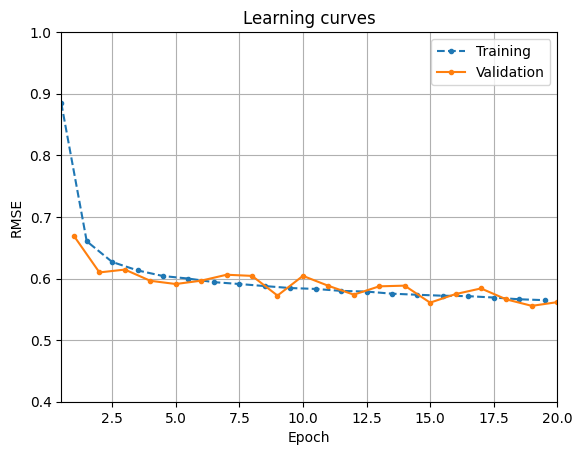

In [62]:
import matplotlib.pyplot as plt
def train2(model, optimizer, criterion, metric, train_loader, valid_loader,
               n_epochs):
    history = {"train_losses": [], "train_metrics": [], "valid_metrics": []}
    for epoch in range(n_epochs):
        total_loss = 0.
        metric.reset()
        for X_batch, y_batch in train_loader:
            model.train()
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            total_loss += loss.item()
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            metric.update(y_pred, y_batch)
        mean_loss = total_loss / len(train_loader)
        history["train_losses"].append(mean_loss)
        history["train_metrics"].append(metric.compute().item())
        history["valid_metrics"].append(
            evaluate_tm(model, valid_loader, metric).item())
        print(f"Epoch {epoch + 1}/{n_epochs}, "
              f"train loss: {history['train_losses'][-1]:.4f}, "
              f"train metric: {history['train_metrics'][-1]:.4f}, "
              f"valid metric: {history['valid_metrics'][-1]:.4f}")
    return history

torch.manual_seed(42)
learning_rate = 0.01
model = nn.Sequential(
    nn.Linear(n_features, 50), nn.ReLU(),
    nn.Linear(50, 40), nn.ReLU(),
    nn.Linear(40, 30), nn.ReLU(),
    nn.Linear(30, 1)
)
model = model.to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, momentum=0)
mse = nn.MSELoss()
rmse = torchmetrics.MeanSquaredError(squared=False).to(device)
history = train2(model, optimizer, mse, rmse, train_loader, valid_loader,
                 n_epochs)

# Since we compute the training metric
plt.plot(np.arange(n_epochs) + 0.5, history["train_metrics"], ".--",
         label="Training")
plt.plot(np.arange(n_epochs) + 1.0, history["valid_metrics"], ".-",
         label="Validation")
plt.xlabel("Epoch")
plt.ylabel("RMSE")
plt.grid()
plt.title("Learning curves")
plt.axis([0.5, 20, 0.4, 1.0])
plt.legend()
plt.show()

In [63]:
class WideAndDeep(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.deep_stack = nn.Sequential(
            nn.Linear(n_features, 50), nn.ReLU(),
            nn.Linear(50, 40), nn.ReLU(),
            nn.Linear(40,30), nn.ReLU(),
        )
        self.output_layer = nn.Linear(30 + n_features, 1)
    
    def forward(self, X):
        deep_output = self.deep_stack(X)
        wide_and_deep = torch.concat([X, deep_output],dim=1)
        return self.output_layer(wide_and_deep)

In [64]:
torch.manual_seed(42)
model = WideAndDeep(n_features).to(device)
learning_rate = 0.002

In [65]:
optimizer = torch.optim.SGD(model.parameters(), lr = learning_rate, momentum=0)
mse = nn.MSELoss()
rmse = torchmetrics.MeanSquaredError(squared=False).to(device)
history = train2(model, optimizer, mse, rmse, train_loader, valid_loader, n_epochs)

Epoch 1/20, train loss: 1.7802, train metric: 1.3344, valid metric: 0.8690
Epoch 2/20, train loss: 0.6201, train metric: 0.7875, valid metric: 0.9492
Epoch 3/20, train loss: 0.5900, train metric: 0.7682, valid metric: 0.7331
Epoch 4/20, train loss: 0.5607, train metric: 0.7488, valid metric: 0.7771
Epoch 5/20, train loss: 0.5408, train metric: 0.7353, valid metric: 0.7967
Epoch 6/20, train loss: 0.5244, train metric: 0.7241, valid metric: 0.7098
Epoch 7/20, train loss: 0.5070, train metric: 0.7119, valid metric: 0.7419
Epoch 8/20, train loss: 0.4941, train metric: 0.7030, valid metric: 0.6750
Epoch 9/20, train loss: 0.4798, train metric: 0.6928, valid metric: 0.6762
Epoch 10/20, train loss: 0.4657, train metric: 0.6825, valid metric: 0.6678
Epoch 11/20, train loss: 0.4538, train metric: 0.6736, valid metric: 0.6617
Epoch 12/20, train loss: 0.4441, train metric: 0.6665, valid metric: 0.6651
Epoch 13/20, train loss: 0.4328, train metric: 0.6580, valid metric: 0.6803
Epoch 14/20, train lo

In [66]:
class WideAndDeepV2(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.deep_stack = nn.Sequential(
            nn.Linear(n_features - 2, 50),nn.ReLU(),
            nn.Linear(50, 40), nn.ReLU(),
            nn.Linear(40, 30), nn.ReLU(),
        )
        self.output_layer = nn.Linear(30 + 5, 1)
    
    def forward(self, X):
        X_wide = X[:, :5]
        X_deep = X[: , 2:]
        deep_output = self.deep_stack(X_deep)
        wide_and_deep = torch.concat([X_wide,deep_output], dim=1)
        return self.output_layer(wide_and_deep)
torch.manual_seed(42)
model = WideAndDeepV2(n_features).to(device)
learning_rate = 0.002
optimizer = torch.optim.SGD(model.parameters(),lr = learning_rate, momentum=0)
mse = nn.MSELoss()
rmse = torchmetrics.MeanSquaredError(squared=False).to(device)
history=train2(model, optimizer, mse, rmse, train_loader, valid_loader, n_epochs)

Epoch 1/20, train loss: 1.8482, train metric: 1.3598, valid metric: 0.9100
Epoch 2/20, train loss: 0.6282, train metric: 0.7927, valid metric: 0.8028
Epoch 3/20, train loss: 0.5763, train metric: 0.7591, valid metric: 0.7567
Epoch 4/20, train loss: 0.5413, train metric: 0.7356, valid metric: 0.7290
Epoch 5/20, train loss: 0.5099, train metric: 0.7142, valid metric: 0.7011
Epoch 6/20, train loss: 0.4841, train metric: 0.6958, valid metric: 0.6816
Epoch 7/20, train loss: 0.4656, train metric: 0.6824, valid metric: 0.6670
Epoch 8/20, train loss: 0.4526, train metric: 0.6728, valid metric: 0.6576
Epoch 9/20, train loss: 0.4438, train metric: 0.6662, valid metric: 0.6539
Epoch 10/20, train loss: 0.4380, train metric: 0.6618, valid metric: 0.6498
Epoch 11/20, train loss: 0.4326, train metric: 0.6577, valid metric: 0.6470
Epoch 12/20, train loss: 0.4284, train metric: 0.6546, valid metric: 0.6447
Epoch 13/20, train loss: 0.4253, train metric: 0.6521, valid metric: 0.6452
Epoch 14/20, train lo

In [67]:
class WideAndDeepV3(nn.Module):
    def __init__(self,n_features):
        super().__init__()
        self.deep_stack = nn.Sequential(
            nn.Linear(n_features - 2, 50), nn.ReLU(),
            nn.Linear(50, 40), nn.ReLU(),
            nn.Linear(40, 30), nn.ReLU(),
        )
        self.output_layer = nn.Linear(30 + 5, 1)
    
    def forward(self, X_wide, X_deep):
        deep_output = self.deep_stack(X_deep)
        wide_and_deep = torch.concat([X_wide, deep_output], dim=1)
        return self.output_layer(wide_and_deep)

In [68]:
torch.manual_seed(42)
train_data_wd = TensorDataset(X_train[:, :5], X_train[:, 2:], y_train)
train_loader_wd = DataLoader(train_data_wd, batch_size=32, shuffle=True)
valid_data_wd = TensorDataset(X_valid[:, :5], X_valid[:, 2:], y_valid)
valid_loader_wd = DataLoader(valid_data_wd, batch_size=32)
test_data_wd = TensorDataset(X_test[:, :5], X_test[:, 2:], y_test)
test_loader_wd = DataLoader(test_data_wd, batch_size=32)

In [69]:
def evaluate_multi_in(model, data_loader, metric):
    model.eval()
    metric.reset()
    with torch.no_grad():
        for X_batch_wide, X_batch_deep, y_batch in data_loader:
            X_batch_wide = X_batch_wide.to(device)
            X_batch_deep = X_batch_deep.to(device)
            y_batch = y_batch.to(device)
            y_pred = model(X_batch_wide, X_batch_deep)
            metric.update(y_pred, y_batch)
    return metric.compute()

def train_multi_in(model, optimizer, criterion, metric, train_loader, valid_loader, n_epochs):
    history = {"train_losses": [], "train_metrics": [], "valid_metrics": []}
    for epoch in range(n_epochs):
        total_loss = 0 
        metric.reset()
        for *X_batch_inputs, y_batch in train_loader:
            model.train()
            X_batch_inputs = [X.to(device) for X in X_batch_inputs]
            y_batch = y_batch.to(device)
            y_pred = model(*X_batch_inputs)
            loss = criterion(y_pred, y_batch)
            total_loss += loss.item()
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            metric.update(y_pred, y_batch)
        mean_loss = total_loss / len(train_loader)
        mean_loss = total_loss / len(train_loader)
        history["train_losses"].append(mean_loss)
        history["train_metrics"].append(metric.compute().item())
        history["valid_metrics"].append(
            evaluate_multi_in(model, valid_loader, metric).item())
        print(f"Epoch {epoch + 1}/{n_epochs}, "
              f"train loss: {history['train_losses'][-1]:.4f}, "
              f"train metric: {history['train_metrics'][-1]:.4f}, "
              f"valid metric: {history['valid_metrics'][-1]:.4f}")
    return history

torch.manual_seed(42)
learning_rate = 0.01
model = WideAndDeepV3(n_features).to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, momentum=0)
mse = nn.MSELoss()
rmse = torchmetrics.MeanSquaredError(squared=False).to(device)
history = train_multi_in(model, optimizer, mse, rmse, train_loader_wd, valid_loader_wd,
                         n_epochs)

Epoch 1/20, train loss: 0.8366, train metric: 0.9148, valid metric: 0.6892
Epoch 2/20, train loss: 0.4627, train metric: 0.6803, valid metric: 0.6455
Epoch 3/20, train loss: 0.4319, train metric: 0.6572, valid metric: 0.6374
Epoch 4/20, train loss: 0.4259, train metric: 0.6525, valid metric: 0.6512
Epoch 5/20, train loss: 0.4120, train metric: 0.6420, valid metric: 0.6305
Epoch 6/20, train loss: 0.4040, train metric: 0.6356, valid metric: 0.6287
Epoch 7/20, train loss: 0.4005, train metric: 0.6330, valid metric: 0.6252
Epoch 8/20, train loss: 0.3976, train metric: 0.6306, valid metric: 0.6158
Epoch 9/20, train loss: 0.3883, train metric: 0.6230, valid metric: 0.7407
Epoch 10/20, train loss: 0.3866, train metric: 0.6218, valid metric: 0.6063
Epoch 11/20, train loss: 0.3752, train metric: 0.6125, valid metric: 0.5974
Epoch 12/20, train loss: 0.3704, train metric: 0.6087, valid metric: 0.5888
Epoch 13/20, train loss: 0.3677, train metric: 0.6063, valid metric: 0.5981
Epoch 14/20, train lo

In [70]:
class WideAndDeepDataset(torch.utils.data.Dataset):
    def __init__(self, X_wide, X_deep, y):
        self.X_wide = X_wide
        self.X_deep = X_deep
        self.y = y
    
    def __len__(self):
        return len(self.y)
    
    def __getitem__(self, idx):
        input_dict = {'X_wide':self.X_wide[idx], 'X_deep':self.X_deep[idx]}
        return input_dict, self.y[idx]

In [71]:
torch.manual_seed(42)
train_data_named = WideAndDeepDataset(
    X_wide=X_train[:, :5], X_deep=X_train[:,2:], y=y_train)
train_loader_named = DataLoader(train_data_named, batch_size=32, shuffle=True)
valid_data_named =WideAndDeepDataset(
    X_wide=X_valid[:, :5],X_deep = X_valid[:,2:],y=y_valid)
valid_loader_named = DataLoader(valid_data_named, batch_size=32)
test_data_named =WideAndDeepDataset(
    X_wide=X_test[:, :5],X_deep = X_test[:,2:],y=y_test)
test_loader_named = DataLoader(test_data_named, batch_size=32)


In [72]:
def evaluate_named(model, data_loader, metric):
    model.eval()
    metric.reset()  # reset the metric at the beginning
    with torch.no_grad():
        for inputs, y_batch in data_loader:
            inputs = {name: X.to(device) for name, X in inputs.items()}
            y_batch = y_batch.to(device)
            y_pred = model(X_wide=inputs["X_wide"], X_deep=inputs["X_deep"])
            metric.update(y_pred, y_batch)
    return metric.compute()  # compute the final result at the end

def train_named(model, optimizer, criterion, metric, train_loader,
                   valid_loader, n_epochs):
    history = {"train_losses": [], "train_metrics": [], "valid_metrics": []}
    for epoch in range(n_epochs):
        total_loss = 0.
        metric.reset()
        for inputs, y_batch in train_loader:
            model.train()
            inputs = {name: X.to(device) for name, X in inputs.items()}
            y_batch = y_batch.to(device)
            y_pred = model(**inputs)
            loss = criterion(y_pred, y_batch)
            total_loss += loss.item()
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            metric.update(y_pred, y_batch)
        mean_loss = total_loss / len(train_loader)
        history["train_losses"].append(mean_loss)
        history["train_metrics"].append(metric.compute().item())
        history["valid_metrics"].append(
            evaluate_named(model, valid_loader, metric).item())
        print(f"Epoch {epoch + 1}/{n_epochs}, "
              f"train loss: {history['train_losses'][-1]:.4f}, "
              f"train metric: {history['train_metrics'][-1]:.4f}, "
              f"valid metric: {history['valid_metrics'][-1]:.4f}")
    return history

torch.manual_seed(42)
learning_rate = 0.01
model = WideAndDeepV3(n_features).to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, momentum=0)
mse = nn.MSELoss()
rmse = torchmetrics.MeanSquaredError(squared=False).to(device)
history = train_named(model, optimizer, mse, rmse, train_loader_named,
                      valid_loader_named, n_epochs)

Epoch 1/20, train loss: 0.8366, train metric: 0.9148, valid metric: 0.6892
Epoch 2/20, train loss: 0.4627, train metric: 0.6803, valid metric: 0.6455
Epoch 3/20, train loss: 0.4319, train metric: 0.6572, valid metric: 0.6374
Epoch 4/20, train loss: 0.4259, train metric: 0.6525, valid metric: 0.6512
Epoch 5/20, train loss: 0.4120, train metric: 0.6420, valid metric: 0.6305
Epoch 6/20, train loss: 0.4040, train metric: 0.6356, valid metric: 0.6287
Epoch 7/20, train loss: 0.4005, train metric: 0.6330, valid metric: 0.6252
Epoch 8/20, train loss: 0.3976, train metric: 0.6306, valid metric: 0.6158
Epoch 9/20, train loss: 0.3883, train metric: 0.6230, valid metric: 0.7407
Epoch 10/20, train loss: 0.3866, train metric: 0.6218, valid metric: 0.6063
Epoch 11/20, train loss: 0.3752, train metric: 0.6125, valid metric: 0.5974
Epoch 12/20, train loss: 0.3704, train metric: 0.6087, valid metric: 0.5888
Epoch 13/20, train loss: 0.3677, train metric: 0.6063, valid metric: 0.5981
Epoch 14/20, train lo

In [73]:
class WideAndDeepV4(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.deep_stack = nn.Sequential(
            nn.Linear(n_features - 2, 50), nn.ReLU(),
            nn.Linear(50, 40), nn.ReLU(),
            nn.Linear(40, 30), nn.ReLU(),
        )
        self.output_layer = nn.Linear(30 + 5, 1)
        self.aux_output_layer = nn.Linear(30, 1)
    
    def forward(self, X_wide, X_deep):
        deep_output = self.deep_stack(X_deep)
        wide_and_deep = torch.concat([X_wide, deep_output], dim=1)
        main_output = self.output_layer(wide_and_deep)
        aux_output = self.aux_output_layer(deep_output)
        return main_output, aux_output

In [74]:
import torchmetrics

def evaluate_multi_out(model, data_loader, metric):
    model.eval()
    metric.reset()
    with torch.no_grad():
        for inputs, y_batch in data_loader:
            inputs = {name: X.to(device) for name, X in inputs.items()}
            y_batch = y_batch.to(device)
            y_pred, _ = model(**inputs)
            metric.update(y_pred, y_batch)
    return metric.compute()

def train_multi_out(model, optimizer, criterion, metric, train_loader,
                   valid_loader, n_epochs):
    history = {"train_losses": [], "train_metrics": [], "valid_metrics": []}
    for epoch in range(n_epochs):
        total_loss = 0.
        metric.reset()
        for inputs, y_batch in train_loader:
            model.train()
            inputs = {name: X.to(device) for name, X in inputs.items()}
            y_batch = y_batch.to(device)
            y_pred, y_pred_aux = model(**inputs)
            main_loss = criterion(y_pred, y_batch)
            aux_loss = criterion(y_pred_aux, y_batch)
            loss = 0.8 * main_loss + 0.2 * aux_loss
            total_loss += loss.item()
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            metric.update(y_pred, y_batch)
        mean_loss = total_loss / len(train_loader)
        history["train_losses"].append(mean_loss)
        history["train_metrics"].append(metric.compute().item())
        history["valid_metrics"].append(
            evaluate_multi_out(model, valid_loader, metric).item())
        print(f"Epoch {epoch + 1}/{n_epochs}, "
              f"train loss: {history['train_losses'][-1]:.4f}, "
              f"train metric: {history['train_metrics'][-1]:.4f}, "
              f"valid metric: {history['valid_metrics'][-1]:.4f}")
    return history

torch.manual_seed(42)
learning_rate = 0.01
model = WideAndDeepV4(n_features).to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, momentum=0)
mse = nn.MSELoss()
rmse = torchmetrics.MeanSquaredError(squared=False).to(device)
history = train_multi_out(model, optimizer, mse, rmse, train_loader_named,
                          valid_loader_named, n_epochs)

Epoch 1/20, train loss: 1.0693, train metric: 0.9506, valid metric: 0.7085
Epoch 2/20, train loss: 0.5817, train metric: 0.6946, valid metric: 0.6607
Epoch 3/20, train loss: 0.5010, train metric: 0.6581, valid metric: 0.6425
Epoch 4/20, train loss: 0.4690, train metric: 0.6497, valid metric: 0.6654
Epoch 5/20, train loss: 0.4503, train metric: 0.6420, valid metric: 0.6338
Epoch 6/20, train loss: 0.4387, train metric: 0.6373, valid metric: 0.6563
Epoch 7/20, train loss: 0.4315, train metric: 0.6330, valid metric: 0.6193
Epoch 8/20, train loss: 0.4249, train metric: 0.6302, valid metric: 0.6167
Epoch 9/20, train loss: 0.4116, train metric: 0.6202, valid metric: 0.6450
Epoch 10/20, train loss: 0.4085, train metric: 0.6198, valid metric: 0.5938
Epoch 11/20, train loss: 0.4073, train metric: 0.6197, valid metric: 0.5959
Epoch 12/20, train loss: 0.3914, train metric: 0.6078, valid metric: 0.6073
Epoch 13/20, train loss: 0.3847, train metric: 0.6033, valid metric: 0.5815
Epoch 14/20, train lo

In [75]:
import torchvision
import torchvision.transforms.v2 as T

toTensor = T.Compose([T.ToImage(), T.ToDtype(torch.float32, scale=True)])

train_and_valid_data = torchvision.datasets.FashionMNIST(
    root='datasets', train=True, download=True, transform=toTensor)
test_data = torchvision.datasets.FashionMNIST(
    root='datasets', train=False, download=True, transform=toTensor)
torch.manual_seed(42)
train_data, valid_data = torch.utils.data.random_split(
    train_and_valid_data, [55_000, 5_000])

100%|██████████| 26.4M/26.4M [00:02<00:00, 9.06MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 207kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.85MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 15.9MB/s]


In [76]:
torch.manual_seed(42)
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_data, batch_size=32)
test_loader = DataLoader(test_data, batch_size=32)

In [77]:
X_sample, y_sample = train_data[0]

In [78]:
X_sample.shape

torch.Size([1, 28, 28])

In [79]:
X_sample.dtype

torch.float32

In [80]:
train_and_valid_data.classes[y_sample]

'Ankle boot'

In [81]:
class ImageClassifier(nn.Module):
    def __init__(self, n_inputs, n_hidden1, n_hidden2, n_classes):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Flatten(),
            nn.Linear(n_inputs, n_hidden1),
            nn.ReLU(),
            nn.Linear(n_hidden1, n_hidden2),
            nn.ReLU(),
            nn.Linear(n_hidden2, n_classes)
        )
    
    def forward(self, X):
        return self.mlp(X)
torch.manual_seed(42)
model = ImageClassifier(n_inputs=1 * 28 * 28, n_hidden1=300, n_hidden2=100,
                        n_classes=10).to(device)
xentropy= nn.CrossEntropyLoss()

In [82]:
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)
accuracy = torchmetrics.Accuracy(task='multiclass', num_classes=10).to(device)
_ = train2(model, optimizer, xentropy, accuracy, train_loader, valid_loader, n_epochs)

Epoch 1/20, train loss: 0.6058, train metric: 0.7816, valid metric: 0.8416
Epoch 2/20, train loss: 0.4059, train metric: 0.8497, valid metric: 0.8372
Epoch 3/20, train loss: 0.3633, train metric: 0.8663, valid metric: 0.8530
Epoch 4/20, train loss: 0.3359, train metric: 0.8762, valid metric: 0.8660
Epoch 5/20, train loss: 0.3147, train metric: 0.8835, valid metric: 0.8754
Epoch 6/20, train loss: 0.2991, train metric: 0.8881, valid metric: 0.8666
Epoch 7/20, train loss: 0.2859, train metric: 0.8916, valid metric: 0.8622
Epoch 8/20, train loss: 0.2745, train metric: 0.8971, valid metric: 0.8722
Epoch 9/20, train loss: 0.2639, train metric: 0.9007, valid metric: 0.8834
Epoch 10/20, train loss: 0.2531, train metric: 0.9041, valid metric: 0.8810
Epoch 11/20, train loss: 0.2463, train metric: 0.9068, valid metric: 0.8850
Epoch 12/20, train loss: 0.2353, train metric: 0.9109, valid metric: 0.8910
Epoch 13/20, train loss: 0.2303, train metric: 0.9125, valid metric: 0.8870
Epoch 14/20, train lo

In [83]:
model.eval()
X_new, y_new = next(iter(valid_loader))
X_new = X_new[:3].to(device)
with torch.no_grad():
    y_pred_logits = model(X_new)
y_pred = y_pred_logits.argmax(dim=1) 
y_pred

tensor([7, 4, 2], device='cuda:0')

In [84]:
[train_and_valid_data.classes[index] for index in y_pred]

['Sneaker', 'Coat', 'Pullover']

In [85]:
y_new[:3]

tensor([7, 4, 2])

In [87]:
import torch.nn.functional as F
y_proba = F.softmax(y_pred_logits, dim=1)
y_proba.round(decimals=3)

tensor([[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0010, 0.0000, 0.9110, 0.0000,
         0.0880],
        [0.0000, 0.0000, 0.0040, 0.0000, 0.9960, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.6250, 0.0000, 0.3350, 0.0000, 0.0390, 0.0000, 0.0000,
         0.0000]], device='cuda:0')

In [88]:
y_top4_values, y_top4_indices = torch.topk(y_pred_logits, k=4, dim=1)
y_top4_probas = F.softmax(y_top4_values, dim=1)
y_top4_probas.round(decimals=3)

tensor([[0.9110, 0.0880, 0.0010, 0.0000],
        [0.9960, 0.0040, 0.0000, 0.0000],
        [0.6250, 0.3350, 0.0390, 0.0000]], device='cuda:0')

In [89]:
y_top4_indices

tensor([[7, 9, 5, 8],
        [4, 2, 6, 0],
        [2, 4, 6, 0]], device='cuda:0')

In [ ]:
sum([param.numel() for param in model.parameters()])

266610